# 02 — ベースライン測定：中古車価格はどこまで当てられるか

シエンタ 5,507台のデータで、**今持っている情報だけで価格をどこまで当てられるか**を測る。

## なぜこれを最初にやるのか

これから作る `unfold`（伊藤さんの仕様書のライブラリ）が「精度が上がった」と主張するには、
**比べる相手**が要る。相手がいないと「誤差12万円でした」と言われても、
それが良いのか悪いのか誰にも判断できない。

この「比べる相手」を **ベースライン（baseline / 基準線）** と呼ぶ。このノートブックで作るのはそれ。

やり方は、**情報を1段ずつ足していく「はしご」**を組む。
隣り合う段の差が、そのとき足したものの効果になる。

| 段 | 内容 | 何がわかるか |
|---|---|---|
| 0 | 予測しない（全部を中央値と答える） | これを下回るモデルは無価値、という床 |
| A1 | 線形回帰 ＋ 従来の列 | **従来手法の限界＝出発点** |
| A2 | LightGBM ＋ 同じ列 | モデルを替えただけの効果 |
| B | ＋ クレンジングで増えた列 | 新しい列を作った効果 |
| C | ＋ 装備テキスト（TF-IDF） | **LLMを使わずにテキストを入れた到達点** |

**C が本命の比較対象。** `unfold` の機能A は「非構造テキストを特徴量にする」機構だが、
TF-IDF で同じだけ縮むならその機構は要らない。機能A の価値は C からの上積みで測る。

---

## 0. セットアップ

上から順に **Shift + Enter** で実行する。Jupyter は実行した順に状態が変わるので、
途中のセルだけ動かすと `NameError` になる。順番がわからなくなったら
**Run → Run All Above** で復旧できる。

モデルの定義は `scripts/` 側に置いてある（このノートブックと `python scripts/run_baselines.py`
で同じ結果が出るようにするため）。ここではそれを import して使う。

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 実行中の Python の確認 ---------------------------------------
print("Python :", sys.version.split()[0])
print("実行元 :", sys.executable)
assert ".venv" in sys.executable, (
    "カーネルが .venv になっていません。右上の『カーネルの選択』で .venv を選び直してください。"
)

# --- パス設定。scripts/ を import できるようにする -----------------
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))

# --- 日本語フォント（OS ごとに違うので入っているものを選ぶ）-------
from plot_style import use_japanese_font
use_japanese_font()

from eval_protocol import (
    TARGET, TEXT_COL, LEGACY_NUM, LEGACY_BOOL, LEGACY_CAT, EXTRA_NUM, EXTRA_CAT,
    load_dataset, cross_validate,
)
from run_baselines import predict_median, make_linear, make_lgbm

print("準備完了")

Python : 3.12.14
実行元 : /Users/attuan/carprice/.venv/bin/python
準備完了


---

## 1. データを見る

`sampledata/processed/usedsienta_clean.parquet` は、2026年3月にカーセンサーから
スクレイピングしたシエンタの中古車情報を、[scripts/clean_sienta.py](../scripts/clean_sienta.py)
で整形したもの。1行が1台。

価格が「応談」で数値が入っていない6行だけ落とす。

In [2]:
df = load_dataset()
df[["車両本体価格_万円", "年式", "車齢", "走行距離_km", "グレード名",
    "修復歴あり", "保証付", "ハイブリッド", "都道府県", "装備テキスト"]].head(5)

データ: sampledata/processed/usedsienta_clean.parquet
  5,513 行 → 5,507 行（価格欠損 6 行を除外）
  価格: 中央値 185.7 万円 / 平均 194.9 万円 / 範囲 13〜432 万円


,車両本体価格_万円,年式,車齢,走行距離_km,グレード名,修復歴あり,保証付,ハイブリッド,都道府県,装備テキスト
0,216.3,2024,2,14000.0,G,False,False,True,千葉県,R6年登録 ディスプレイオーディオ 禁煙車 バックカメラ レーダークルーズコントロール 両側...
1,145.4,2023,3,86000.0,G,False,False,True,新潟県,禁煙車 純正8インチディスプレイオーディオ バックカメラ 両側電動スライドドア トヨタセーフ...
2,145.9,2023,3,80000.0,G,False,False,True,新潟県,禁煙車 純正8インチディスプレイオーディオ バックカメラ 両側電動スライドドア トヨタセーフ...
3,90.3,2018,8,70000.0,G クエロ,False,True,False,愛知県,禁煙車 7人乗り 純正SDナビ バックカメラ 両側電動ドア シートヒーター ビルトインETC...
4,145.2,2019,7,27000.0,X ウェルキャブ 車いす仕様車 タイプI 助手席側セカンドシート無,False,True,False,愛知県,ワンオーナー/バックカメラ/ドラレコ前


### 価格の分布を見る

平均だけ見て判断すると事故る。まず形を見る。

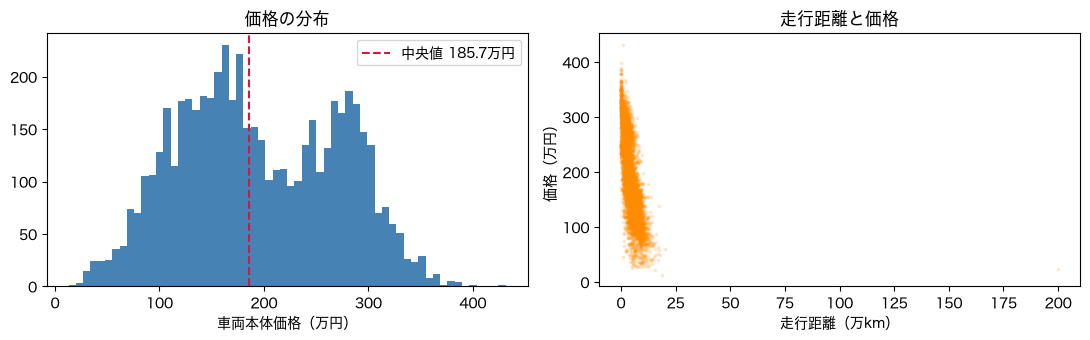

count    5507.0
mean      194.9
std        76.0
min        13.0
1%         44.0
25%       135.2
50%       185.7
75%       263.0
99%       349.0
max       431.5
Name: 車両本体価格_万円, dtype: float64

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df[TARGET], bins=60, color="steelblue")
ax[0].axvline(df[TARGET].median(), color="crimson", ls="--",
              label=f"中央値 {df[TARGET].median():.1f}万円")
ax[0].set_title("価格の分布"); ax[0].set_xlabel("車両本体価格（万円）"); ax[0].legend()

ax[1].scatter(df["走行距離_km"] / 10000, df[TARGET], s=3, alpha=0.15, color="darkorange")
ax[1].set_title("走行距離と価格"); ax[1].set_xlabel("走行距離（万km）"); ax[1].set_ylabel("価格（万円）")
plt.tight_layout(); plt.show()

df[TARGET].describe(percentiles=[.01, .25, .5, .75, .99]).round(1)

**読み方：** 右の散布図で、走行距離が増えると価格が下がるが、**その下がり方が直線ではない**
ことに注目する。最初の数万kmで急に落ち、そこから先はなだらか。
この「曲がり」を表現できるかどうかが、後で線形回帰と LightGBM の差になって出てくる。

---

## 2. 何を当てるゲームなのか

- **目的変数（target）** … 当てたいもの。ここでは `車両本体価格_万円`
  - `支払総額` ではない。支払総額には店舗ごとの諸費用が乗っていて、
    車そのものの価値以外のバラつきが混ざるため
- **特徴量（feature）** … 手がかりにする列

特徴量は3グループに分けてある。この分け方が「はしご」の段に対応する。

In [3]:
print("【従来列】スクレイピング当時の回帰分析と同じ構成（A1/A2 で使う）")
print("  数値 :", LEGACY_NUM)
print("  0/1  :", LEGACY_BOOL)
print("  種類 :", LEGACY_CAT)
print()
print("【追加列】クレンジングで新たに取り出せた列（B で足す）")
print("  数値 :", EXTRA_NUM)
print("  種類 :", EXTRA_CAT)
print()
print("【非構造テキスト】unfold 機能A の入力になる列（C で足す）")
print("  ", TEXT_COL)
print()
print("装備テキストの例:")
for t in df[TEXT_COL].dropna().head(3):
    print("  ", t[:70], "...")

【従来列】スクレイピング当時の回帰分析と同じ構成（A1/A2 で使う）
  数値 : ['車齢', '走行距離_km']
  0/1  : ['修復歴あり', '保証付', 'ハイブリッド']
  種類 : ['車検区分', '都道府県']

【追加列】クレンジングで新たに取り出せた列（B で足す）
  数値 : ['車検残月数', '装備数']
  種類 : ['グレード名', '色_基本']

【非構造テキスト】unfold 機能A の入力になる列（C で足す）
   装備テキスト

装備テキストの例:
   R6年登録 ディスプレイオーディオ 禁煙車 バックカメラ レーダークルーズコントロール 両側電動スライドドア プッシュスタート ETC スマ ...
   禁煙車 純正8インチディスプレイオーディオ バックカメラ 両側電動スライドドア トヨタセーフティセンス ブラインドスポットモニター LEDヘ ...
   禁煙車 純正8インチディスプレイオーディオ バックカメラ 両側電動スライドドア トヨタセーフティセンス ブラインドスポットモニター LEDヘ ...


---

## 3. 「当たっている」をどう測るか — 評価指標

予測が出せても、当たり具合を数字にしないと比較できない。4つ使う。

### MAE（平均絶対誤差 / Mean Absolute Error）— 主指標

**予測が平均で何万円ズレたか。**

| 実際 | 予測 | ズレ |
|---|---|---|
| 200万円 | 190万円 | 10万円 |
| 150万円 | 165万円 | 15万円 |
| 300万円 | 295万円 | 5万円 |

→ MAE = (10 + 15 + 5) ÷ 3 = **10万円**

「絶対」は、−10万円と+10万円を区別せず両方10万円として数えるという意味
（区別すると打ち消し合って0になってしまう）。**小さいほど良い。**
一番直感的に読めるので、このプロジェクトの主指標にする。

### RMSE（二乗平均平方根誤差）— 大ハズレを重く罰する版

ズレを2乗してから平均し、最後に平方根を取る。2乗するので 10万円のズレは 100、
50万円のズレは 2500 として数えられる。つまり**たまに大きく外すモデルは RMSE が跳ね上がる。**

MAE と RMSE を並べると、「安定して少しズレる」のか「普段は当たるがたまに大コケする」のかが分かる。

### MAPE（平均絶対誤差率）— ％で見る

300万円の車を10万円外すのと、50万円の車を10万円外すのでは意味が違う。％にすると揃う。

### R²（決定係数）— バラつきをどれだけ説明できたか

0〜1。**大きいほど良い**（他の3つと向きが逆なので注意）。

- R² = 0 … 「全部を平均価格で答える」のと同じ。何も学習できていない
- R² = 1 … 完璧

0.95 なら「価格のバラつきの95%を説明できている」と読む。

---

## 4. ズルをしない仕組み — 交差検証

ここが一番大事。

### なぜ工夫が要るのか

5,507台すべてで学習させ、その**同じ**5,507台で採点したら意味がない。
答えを見ながら答案を書くのと同じで、丸暗記したモデルが最高得点を取ってしまう。

だから **訓練データ**（学習に使う）と **テストデータ**（採点に使う）に分け、
テストデータは学習中いっさい見せない。

### 5分割交差検証（5-fold Cross Validation）

2つに割るだけだと「たまたま簡単な車がテストに来た」という運が効く。そこで：

```
5,507台を5グループ（約1,101台ずつ）にランダム分割

1回目:  [テスト][訓練 ][訓練 ][訓練 ][訓練 ]  → 採点
2回目:  [訓練 ][テスト][訓練 ][訓練 ][訓練 ]  → 採点
3回目:  [訓練 ][訓練 ][テスト][訓練 ][訓練 ]  → 採点
4回目:  [訓練 ][訓練 ][訓練 ][テスト][訓練 ]  → 採点
5回目:  [訓練 ][訓練 ][訓練 ][訓練 ][テスト]  → 採点

5回の平均をそのモデルの成績とする
```

全データが1回ずつテスト役を務めるので、運の影響が減る。
この1回分を **fold（フォールド／折り）** と呼ぶ。

結果に出る `MAE 12.21 (±0.42)` の **±0.42** はこの5回のバラつき。
小さいほど「安定して同じ成績が出る」＝信用できる。

### リーク（leakage / 情報の漏れ）

テストデータの情報がこっそり訓練側に混ざる事故を **リーク** と呼ぶ。
よくあるのは「下処理を全データでやってしまう」パターン。

例：「価格の平均を引いておく」という下処理を5,507台全部でやると、
その平均にはテストデータの価格が入っている＝**答えの一部が漏れている**。
すると実験室では良い点が出るのに本番でまるで当たらないモデルができる。

そこで [scripts/eval_protocol.py](../scripts/eval_protocol.py) の `cross_validate()` は、
**TF-IDF の学習も含めて、すべての下処理を fold 内の訓練データだけで行う**構造にしてある。
以降の実験は全部これを通すので、この点は自動的に守られる。

> `record=False` を付けて呼んでいるのは、`results/leaderboard.csv` に
> 同じ結果を二重登録しないため。記録は `scripts/run_baselines.py` 側の役目にしてある。

---

## 5. 段 0 — 予測しない場合（床）

まず「予測を放棄した場合」を測る。全部の車を**訓練データの中央値**と答えるだけ。
**これを下回れないモデルは存在価値がない**、という床になる。

In [5]:
results = {}
results["0  中央値"] = cross_validate("0  中央値", predict_median, df, record=False)

  fold1  MAE  63.68  RMSE  75.34  MAPE  43.7%  R2 -0.005
  fold2  MAE  63.46  RMSE  75.27  MAPE  41.6%  R2 -0.021
  fold3  MAE  64.68  RMSE  76.95  MAPE  45.3%  R2 -0.013
  fold4  MAE  66.42  RMSE  78.30  MAPE  44.6%  R2 -0.024
  fold5  MAE  64.62  RMSE  76.78  MAPE  43.4%  R2 -0.018
  平均      MAE  64.57 (±1.04)  RMSE  76.53  MAPE  43.7%  R2 -0.016


平均 **64.57万円**ズレる。R² がマイナスなのは「平均で答えるより悪い」という意味で、
中央値を使っているので当然そうなる。

---

## 6. 段 A1 — 線形回帰（従来手法の再現）

### 線形回帰とは

**「価格 ＝ a×走行距離 ＋ b×車齢 ＋ c×修復歴 ＋ … ＋ 定数」という足し算の式**を作る、
一番古典的な手法。松本さんが以前カーセンサーのデータでやった回帰分析がこれにあたる。

- **長所**：係数を見れば「走行距離が1万km増えると◯万円下がる」と直接読める
- **短所**：**足し算の形しか表現できない**

現実には「走行距離は最初の数万kmで急に価値が落ち、そこからなだらか」という曲がった関係
（**非線形**）や、「ハイブリッドかつ低走行のときだけ特別に高い」という組み合わせ効果
（**交互作用**）があるが、線形回帰はこれを表現できない。§1 の散布図で見た曲がりがまさにそれ。

### 文字をどう食わせるか — one-hot エンコーディング（ダミー変数）

モデルは数値しか扱えないので、「千葉県」をそのままは渡せない。
種類が決まっている列は、種類の数だけ 0/1 の列に展開する。

| | 北海道 | 青森県 | … | 千葉県 | … |
|---|---|---|---|---|---|
| 1台目 | 0 | 0 | … | **1** | … |
| 2台目 | 0 | **1** | … | 0 | … |

47都道府県なら47列。これが CLAUDE.md にある「定性情報をダミー変数でしか扱えず
精度に限界があった」の**ダミー変数**。限界というのは、県同士の関係（隣県は似ている等）が
完全に消えることや、列が増えてデータが薄まること（**次元の呪い**）を指す。

> コードでは素の線形回帰ではなく **Ridge（リッジ回帰）** を使っている。
> 47列に展開するとデータの少ない県で係数が異常値に暴れるため、
> 「係数が大きくなりすぎたら罰則を与える」仕組み（**正則化**）を足したもの。考え方は同じ。

In [6]:
results["A1 線形回帰・従来列"] = cross_validate(
    "A1 線形回帰・従来列",
    make_linear(LEGACY_NUM, LEGACY_BOOL, LEGACY_CAT),
    df, record=False,
)

  fold1  MAE  23.47  RMSE  30.36  MAPE  15.0%  R2 0.837
  fold2  MAE  22.19  RMSE  28.59  MAPE  14.6%  R2 0.853


  fold3  MAE  21.89  RMSE  28.79  MAPE  15.9%  R2 0.858
  fold4  MAE  22.58  RMSE  56.73  MAPE  20.4%  R2 0.462
  fold5  MAE  23.69  RMSE  30.30  MAPE  15.5%  R2 0.842
  平均      MAE  22.76 (±0.71)  RMSE  34.95  MAPE  16.3%  R2 0.770


**平均22.76万円ズレる。これがこのプロジェクトの出発点＝「従来手法の限界」。**

fold4 だけ RMSE が 56 前後に跳ねていることに注目。MAE（22.58）は他の fold と変わらないのに
RMSE だけ倍近い＝**普段は当たっているが、数台をとんでもなく外している**。
one-hot した都道府県の係数が、データの少ない県で暴れているのが原因と考えられる。
§3 で「MAE と RMSE を並べると分かることがある」と書いたのは、まさにこういうケース。

---

## 7. 段 A2 — モデルだけ LightGBM に替える

**特徴量は A1 と1列も変えない。** 道具だけ替えると何が起きるかを見る。

### 勾配ブースティング決定木（LightGBM）とは

表形式データ（Excel のような行×列のデータ）では現在**最強クラス**とされる手法。2段階でできている。

**① 決定木（decision tree）**
「走行距離は5万km以上か？ → YESなら次に、年式は2020年以降か？ → …」という**質問のツリー**で
値を出す。if 文の入れ子だと思えばよい。これなら曲がった関係も組み合わせ効果も表現できる。

**② ブースティング（boosting）**
木を1本作れば必ず外れが出る。そこで**「1本目が外した分」を当てる2本目**を作り、
「2本目でも残った外れ」を当てる3本目を作り…と積み重ねる。ここでは700本。

「LightGBM」はこれを高速に実装したライブラリの名前（Microsoft製）。XGBoost も同系統。

In [7]:
results["A2 LightGBM・従来列"] = cross_validate(
    "A2 LightGBM・従来列",
    make_lgbm(LEGACY_NUM, LEGACY_BOOL, LEGACY_CAT),
    df, record=False,
)

  fold1  MAE  17.73  RMSE  23.62  MAPE  10.8%  R2 0.901


  fold2  MAE  17.50  RMSE  23.38  MAPE  10.6%  R2 0.902


  fold3  MAE  16.77  RMSE  22.45  MAPE  10.6%  R2 0.914


  fold4  MAE  17.78  RMSE  22.89  MAPE  11.5%  R2 0.912


  fold5  MAE  17.78  RMSE  23.35  MAPE  11.0%  R2 0.906
  平均      MAE  17.51 (±0.39)  RMSE  23.14  MAPE  10.9%  R2 0.907


**22.76 → 17.51。情報を1つも増やしていないのに 5.25万円改善した。**

これは重要な発見。CLAUDE.md には
「従来の回帰分析では定性情報をダミー変数でしか扱えず精度に限界があった」とあるが、
**限界の少なくとも半分はダミー変数のせいではなく、線形回帰という道具のせいだった。**
同じ情報でも木を使えばここまで縮む。

fold ごとのバラつき（±0.39）も A1（±0.71）より小さく、安定している。

---

## 8. 段 B — クレンジングで増えた列を足す

昨日の [scripts/clean_sienta.py](../scripts/clean_sienta.py) で新たに取り出した4列
（グレード名・色_基本・車検残月数・装備数）を足す。

In [8]:
FULL_NUM = LEGACY_NUM + EXTRA_NUM
FULL_CAT = LEGACY_CAT + EXTRA_CAT

results["B  LightGBM・構造化列フル"] = cross_validate(
    "B  LightGBM・構造化列フル",
    make_lgbm(FULL_NUM, LEGACY_BOOL, FULL_CAT),
    df, record=False,
)

  fold1  MAE  12.83  RMSE  17.55  MAPE   8.3%  R2 0.945


  fold2  MAE  12.68  RMSE  16.68  MAPE   8.0%  R2 0.950


  fold3  MAE  12.70  RMSE  16.77  MAPE   8.5%  R2 0.952


  fold4  MAE  13.16  RMSE  17.23  MAPE   8.7%  R2 0.950


  fold5  MAE  13.05  RMSE  17.88  MAPE   8.4%  R2 0.945
  平均      MAE  12.88 (±0.19)  RMSE  17.22  MAPE   8.4%  R2 0.948


**17.51 → 12.88。4.63万円改善。** 大きい。

ただし4列まとめて足したので、**どれが効いたのかはこの時点では分からない。**
これは §11 のアブレーションで切り分ける。

---

## 9. 段 C — 装備テキストを入れる

ここが `unfold` 機能A の比較対象になる段。

`装備テキスト` は「禁煙車 バックカメラ 両側電動スライドドア ETC …」のような自由な文章で、
都道府県と違って**種類が決まっていない**。one-hot は使えない。

### TF-IDF とは

自由文を数値に変える古典的な方法。

- **TF（Term Frequency / 出現頻度）** … その語が何回出たか
- **IDF（Inverse Document Frequency / 逆文書頻度）** … その語が**どれだけ珍しいか**

掛け合わせると「ほぼ全車に書いてある語（例：禁煙車）は軽く、珍しい語（例：サンルーフ）は重く」なる。
**珍しい語ほどその車を特徴づける情報量が大きい**、という考え方。

2通り試す。

- **単語TF-IDF** … スペース区切りの語をそのまま数える（300列）
- **文字TF-IDF** … 文字2〜4個の並びを数える（1,000列）。
  「純正8インチディスプレイオーディオ」と「ディスプレイオーディオ」のような
  **表記のゆれ**を部分一致で拾えるのが利点。日本語は単語の切れ目が曖昧なので効きやすい

なお TF-IDF は fold ごとに**訓練データだけで作り直している**（§4 のリーク対策）。
文字TF-IDF は1,000列作るので少し時間がかかる。

In [9]:
results["C1 B+装備テキスト(単語TF-IDF)"] = cross_validate(
    "C1 B+装備テキスト(単語TF-IDF)",
    make_lgbm(FULL_NUM, LEGACY_BOOL, FULL_CAT, text="word"),
    df, record=False,
)

  fold1  MAE  12.43  RMSE  17.10  MAPE   8.1%  R2 0.948


  fold2  MAE  12.27  RMSE  16.45  MAPE   7.9%  R2 0.951


  fold3  MAE  12.27  RMSE  16.29  MAPE   8.3%  R2 0.955


  fold4  MAE  12.95  RMSE  17.05  MAPE   8.6%  R2 0.951


  fold5  MAE  12.88  RMSE  17.75  MAPE   8.3%  R2 0.946
  平均      MAE  12.56 (±0.30)  RMSE  16.93  MAPE   8.2%  R2 0.950


In [10]:
results["C2 B+装備テキスト(文字TF-IDF)"] = cross_validate(
    "C2 B+装備テキスト(文字TF-IDF)",
    make_lgbm(FULL_NUM, LEGACY_BOOL, FULL_CAT, text="char"),
    df, record=False,
)

  fold1  MAE  11.97  RMSE  16.53  MAPE   7.7%  R2 0.952


  fold2  MAE  12.01  RMSE  16.17  MAPE   7.6%  R2 0.953


  fold3  MAE  11.73  RMSE  15.51  MAPE   7.8%  R2 0.959


  fold4  MAE  12.46  RMSE  16.73  MAPE   8.4%  R2 0.953


  fold5  MAE  12.90  RMSE  17.49  MAPE   8.4%  R2 0.947
  平均      MAE  12.21 (±0.42)  RMSE  16.49  MAPE   8.0%  R2 0.953


**12.88 → 12.21。合わせて 0.67万円しか改善しない。**

1,300列も足したのにこれだけ、というのがこの実験の要点。理由は §11 で明らかになる。

### おまけ：目的変数を対数にすると改善するか

価格の分布は右に裾を引いていた（§1）。こういうとき、価格そのものではなく
**log(価格)** を予測すると精度が上がることがある。高額帯の広がりが圧縮されて
モデルが扱いやすくなるため。試してみる。

In [11]:
results["C1' C1のlog(価格)版"] = cross_validate(
    "C1' C1のlog(価格)版",
    make_lgbm(FULL_NUM, LEGACY_BOOL, FULL_CAT, text="word", log_target=True),
    df, record=False,
)

  fold1  MAE  12.23  RMSE  16.99  MAPE   7.7%  R2 0.949


  fold2  MAE  12.28  RMSE  16.57  MAPE   7.6%  R2 0.951


  fold3  MAE  12.46  RMSE  16.48  MAPE   8.3%  R2 0.954


  fold4  MAE  12.79  RMSE  17.02  MAPE   8.3%  R2 0.952


  fold5  MAE  13.07  RMSE  17.85  MAPE   8.2%  R2 0.945
  平均      MAE  12.57 (±0.32)  RMSE  16.98  MAPE   8.0%  R2 0.950


12.56 → 12.57。**効果なし。** シエンタ単一車種で価格帯が13〜432万円に収まっており、
裾の広がりが穏やかなので、対数化する旨味がなかったと考えられる。
複数車種に広げて価格帯が数十万〜数千万になれば効いてくる可能性がある。

---

## 10. はしご全体を並べる

In [12]:
tbl = pd.DataFrame(results).T[["MAE", "MAE_std", "RMSE", "MAPE", "R2"]].round(2)
order = ["0  中央値", "A1 線形回帰・従来列", "A2 LightGBM・従来列",
         "B  LightGBM・構造化列フル", "C1 B+装備テキスト(単語TF-IDF)",
         "C2 B+装備テキスト(文字TF-IDF)", "C1' C1のlog(価格)版"]
tbl = tbl.loc[order]
tbl["前段との差"] = tbl["MAE"].diff().round(2)
tbl

,MAE,MAE_std,RMSE,MAPE,R2,前段との差
0 中央値,64.57,1.04,76.53,43.74,-0.02,NaN
A1 線形回帰・従来列,22.76,0.71,34.95,16.29,0.77,-41.81
A2 LightGBM・従来列,17.51,0.39,23.14,10.90,0.91,-5.25
B LightGBM・構造化列フル,12.88,0.19,17.22,8.39,0.95,-4.63
C1 B+装備テキスト(単語TF-IDF),12.56,0.30,16.93,8.22,0.95,-0.32
C2 B+装備テキスト(文字TF-IDF),12.21,0.42,16.49,7.95,0.95,-0.35
C1' C1のlog(価格)版,12.57,0.32,16.98,8.01,0.95,0.36


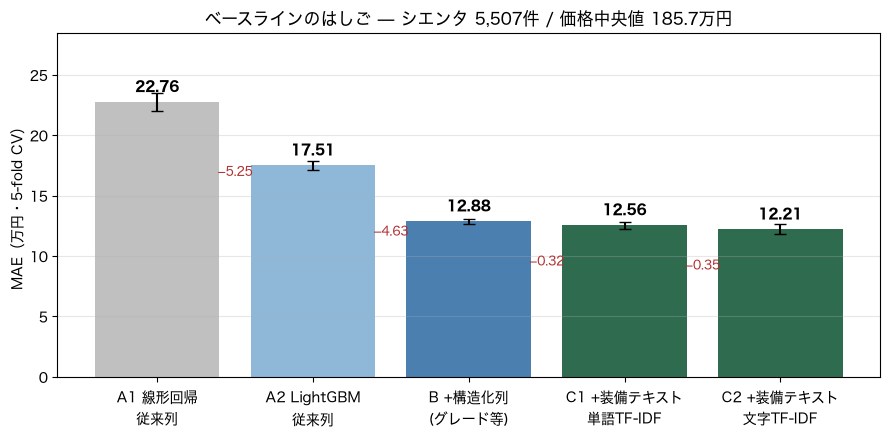

In [13]:
names = order[1:6]
labels = ["A1 線形回帰\n従来列", "A2 LightGBM\n従来列", "B +構造化列\n(グレード等)",
          "C1 +装備テキスト\n単語TF-IDF", "C2 +装備テキスト\n文字TF-IDF"]
vals = tbl.loc[names, "MAE"].to_numpy()
errs = tbl.loc[names, "MAE_std"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(labels, vals, yerr=errs, capsize=4,
              color=["#c0c0c0", "#8fb8d8", "#4a7fb0", "#2e6b4f", "#2e6b4f"])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.9, f"{v:.2f}",
            ha="center", fontsize=10, fontweight="bold")
for i in range(1, len(vals)):
    ax.annotate(f"−{vals[i-1]-vals[i]:.2f}", xy=(i - 0.5, (vals[i-1] + vals[i]) / 2 - 3.5),
                ha="center", fontsize=9, color="#b03030")

ax.set_ylabel("MAE（万円・5-fold CV）")
ax.set_title("ベースラインのはしご — シエンタ 5,507件 / 価格中央値 185.7万円")
ax.set_ylim(0, max(vals) * 1.25); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

最終的に **MAE 12.21万円**。価格中央値が185.7万円なので、**だいたい6〜8%の誤差で当たる**。

---

## 11. アブレーション — B の 4.63万円はどの列から来たのか

### アブレーションとは

**ablation** はもともと「切除」という医学用語。機械学習では、
**部品を1つずつ抜き差しして、どの部品が成果に効いているかを切り分ける実験**を指す。

段 B では4列まとめて足して4.63万円改善したが、これでは**どれが効いたのか分からない**。
そこで A2 の状態から**1列ずつ**足して測り直す。

In [14]:
ab = {}
ab_runs = [
    ("グレード名", LEGACY_NUM, LEGACY_CAT + ["グレード名"], "タイトル文から抽出"),
    ("色_基本",   LEGACY_NUM, LEGACY_CAT + ["色_基本"],   "元から独立した列"),
    ("車検残月数", LEGACY_NUM + ["車検残月数"], LEGACY_CAT, "元から独立した列"),
    ("装備数",    LEGACY_NUM + ["装備数"],    LEGACY_CAT, "タイトル文から抽出"),
]
for label, num, cat, src in ab_runs:
    print(f"[+{label}]")
    m = cross_validate(f"Ab +{label}", make_lgbm(num, LEGACY_BOOL, cat), df, record=False)
    ab[label] = {"MAE": m["MAE"], "改善": results["A2 LightGBM・従来列"]["MAE"] - m["MAE"], "出どころ": src}
    print()

ab_tbl = pd.DataFrame(ab).T.sort_values("改善", ascending=False)
ab_tbl[["MAE", "改善"]] = ab_tbl[["MAE", "改善"]].astype(float).round(2)
ab_tbl

[+グレード名]


  fold1  MAE  13.56  RMSE  18.37  MAPE   8.8%  R2 0.940


  fold2  MAE  13.20  RMSE  17.53  MAPE   8.3%  R2 0.945


  fold3  MAE  13.42  RMSE  17.69  MAPE   8.9%  R2 0.946


  fold4  MAE  13.87  RMSE  18.32  MAPE   9.3%  R2 0.944


...

  fold2  MAE  17.15  RMSE  22.87  MAPE  10.4%  R2 0.906


  fold3  MAE  16.59  RMSE  22.01  MAPE  10.4%  R2 0.917


  fold4  MAE  17.42  RMSE  22.56  MAPE  11.1%  R2 0.915


  fold5  MAE  17.48  RMSE  23.04  MAPE  10.9%  R2 0.908
  平均      MAE  17.21 (±0.33)  RMSE  22.77  MAPE  10.7%  R2 0.910



,MAE,改善,出どころ
グレード名,13.60,3.91,タイトル文から抽出
色_基本,16.79,0.72,元から独立した列
車検残月数,17.15,0.36,元から独立した列
装備数,17.21,0.30,タイトル文から抽出


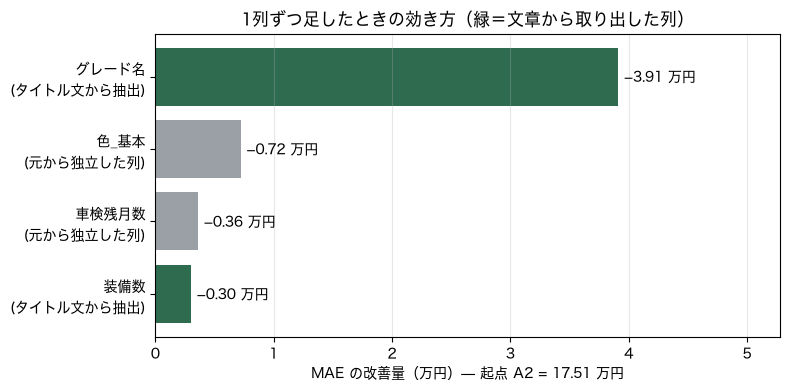

In [15]:
g = ab_tbl["改善"].astype(float)
colors = ["#2e6b4f" if "抽出" in s else "#9aa0a6" for s in ab_tbl["出どころ"]]
lab = [f"{i}\n({s})" for i, s in zip(ab_tbl.index, ab_tbl["出どころ"])]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(lab[::-1], g.to_numpy()[::-1], color=colors[::-1])
for b, v in zip(bars, g.to_numpy()[::-1]):
    ax.text(v + 0.05, b.get_y() + b.get_height() / 2, f"−{v:.2f} 万円", va="center", fontsize=10)
ax.set_xlabel(f"MAE の改善量（万円）— 起点 A2 = {results['A2 LightGBM・従来列']['MAE']:.2f} 万円")
ax.set_title("1列ずつ足したときの効き方（緑＝文章から取り出した列）")
ax.set_xlim(0, g.max() * 1.35); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

**グレード名1列で 3.91万円** — B の改善4.63万円の**85%**がここだった。

グレード名（G / Z / G クエロ / ファンベース G …116種類）は、元データには
**独立した列として存在しない**。カーセンサーのタイトル欄という1本の文章に埋まっていた。

```
「シエンタ ハイブリッド 1.5 G R6年登録　ディスプレイオーディオ　禁煙車　バックカメラ　…」
                        ↑ここ
```

これを昨日のクレンジングで **正規表現**（文字列のパターンを指定して抜き出す記法）で
取り出した。その1列が3.91万円分の価値を持っていた。

考えてみれば当然で、**同じ年式・同じ走行距離でも、グレードが違えば新車価格から違う。**

---

## 12. わかったこと

### 1. 従来手法の限界は MAE 22.76万円。今日それを 12.21万円まで縮めた

約半分。今後すべての比較はこの 12.21 が基準になる。

### 2. 一番効いたのは「文章から構造を取り出すこと」（−3.91万円）

**これはまさに `unfold` の機能A（Feature）がやろうとしている作業。**
「非構造データ（自由な文章や画像）から、機械学習に使える列を作る」——
その価値が、実データで **3.91万円** と定量化できた。仕様書の主張に裏付けが取れた形。

### 3. ただし「装備の羅列」からの伸びしろは薄い（−0.67万円）

同じ文章でも、後半の装備の羅列（バックカメラ、ETC、両側電動スライドドア…）からは
0.67万円しか出ない。理由は**情報が重複しているから**。
「両側電動スライドドアが付いている」は、「グレードが Z だ」と分かった時点でほぼ判明する。

---

## 13. `unfold` への含意（ミーティングの論点）

**① 機能A が超えるべき線は MAE 12.21万円。**
LLM で装備テキストを特徴量にしても、TF-IDF で既に0.67万円取れている以上、
上積みの余地は薄い。ここを目玉にすると成果が数字に出ない危険がある。

**② 本当に狙うべきは「グレード抽出」の側。ただしシエンタだけでは証明できない。**
効いたのはグレード名だが、**それは正規表現で取れてしまった。** LLM を使う理由がない。
しかしこれは**シエンタ1車種しか見ていないから**で、車種を増やすと
メーカーごとに表記の作法がバラバラになり（トヨタの G / Z、ホンダの EX / L、
輸入車の xDrive20d M Sport …）、**正規表現では書ききれなくなる。そこが LLM の出番。**

→ **提案：データを複数車種に広げる。** これが今日の測定から出た一番強い主張。

**③ 教師ラベルの起点がない。**
仕様書は「200 labeled examples you already have」から始まる設計だが、
中古車データに「この文章はグレード G です」という正解表は存在しない。
→ **提案：LLM に数百件だけ正解を作らせ、それを種にする。**

**④ 評価指標が2階層になる。**
仕様書のデモ指標は**中間ラベル**の accuracy（98.6%）だが、
このプロジェクトの最終目標は**価格の MAE**。
**中間ラベルが正確でも価格が当たるとは限らない**——今日それが実際に起きた。
装備テキストの TF-IDF は装備を正確に捉えているが、価格はほとんど改善しなかった。
→ **提案：特徴量の良し悪しは下流の価格 MAE で測る。** 正解ラベル作成が不要になり ③ も回避できる。

**⑤ 画像モダリティは今のデータでは検証できない。**
`画像URL` 列は遅延読み込みのプレースホルダ（`animation_S.gif`）しか取れていない。
詳細ページURLはあるので再取得は可能。または `vehicles.csv` の `image_url`（9割充足）を使う。

---

## 14. まだできていないこと

**埋め込み（embedding）** が試せていない。

埋め込みとは、**文章を数百個の数値の並び（ベクトル）に変換し、意味の近さを距離で測れるようにする**技術。
TF-IDF は「同じ単語が入っているか」しか見ないが、埋め込みなら
「バックカメラ」と「リアカメラ」が別の単語でも意味が近いと分かる。
仕様書の機能A はこの埋め込みを土台にしている。

動かせない理由：このマシンは Intel Mac で、PyTorch（埋め込みモデルを動かすライブラリ）が
2.2.2 までしか対応しておらず、現在入っている numpy 2.5.2 と非互換。
無理に入れると**今動いている環境ごと壊れる**恐れがあるため見送った。

回避策は2つ。

1. APIキーを取得して外部サービスの埋め込み（Voyage / OpenAI）を使う — 導入は実質1行
2. 隔離した別 venv で埋め込みだけ先に計算し、parquet に保存して読み込む

ただし §12-3 から考えて、埋め込みを入れても大きくは変わらない見込み。
それより ② の「複数車種への拡張」を優先すべきと考えている。